In [2]:
import pypsa
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

regions_plot = regions.copy().to_crs(epsg=4258)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [29]:
gasuse = 2000
n = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / f'base_s_50__3H-T-H-B-I-A-dist1_2035_free_{gasuse}.nc')

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [7]:
n.buses.carrier.unique()

array(['AC', 'none', 'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2',
       'battery', 'EV battery', 'oil', 'oil primary',
       'land transport oil', 'urban central heat', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'heat<100 industry',
       'heat100-200 industry', 'heat200-500 industry',
       'heat>500 industry', 'steel', 'hbi', 'steel emission',
       'gas for industry', 'industry methanol', 'naphtha for industry',
       'non-sequestered HVC', 'process emissions', 'coal',
       'coal for industry', 'shipping methanol', 'shipping oil',
       'kerosene for aviation', 'agriculture machinery oil',
       'low voltage', 'home battery', 'rural heat',
       'urban decentral heat'], dtype=object)

In [12]:
n.statistics.withdrawal(groupby=['bus_carrier', 'bus'], aggregate_time=False)

snapshot                                                 2024-01-01 00:00:00  \
component bus_carrier         bus                                              
Load      EV battery          AL0 0 EV battery                      20.34419   
                              AT0 0 EV battery                     220.21750   
                              BA0 0 EV battery                      33.12581   
                              BE0 0 EV battery                     285.09752   
                              BG0 0 EV battery                      82.35436   
...                                                                      ...   
Store     non-sequestered HVC SE1 0 non-sequestered HVC                  NaN   
                              SI0 0 non-sequestered HVC                  NaN   
                              SK0 0 non-sequestered HVC                  NaN   
                              XK0 0 non-sequestered HVC                  NaN   
          oil                 EU oil                                     NaN   

snapshot                                                 2024-01-01 03:00:00  \
component bus_carrier         bus                                              
Load      EV battery          AL0 0 EV battery                      54.97395   
                              AT0 0 EV battery                     602.21977   
                              BA0 0 EV battery                      89.45335   
                              BE0 0 EV battery                     777.47630   
                              BG0 0 EV battery                     385.56258   
...                                                                      ...   
Store     non-sequestered HVC SE1 0 non-sequestered HVC                  NaN   
                              SI0 0 non-sequestered HVC                  NaN   
                              SK0 0 non-sequestered HVC                  NaN   
                              XK0 0 non-sequestered HVC                  NaN   
          oil                 EU oil                                 0.01533   

snapshot                                                 2024-01-01 06:00:00  \
component bus_carrier         bus                                              
Load      EV battery          AL0 0 EV battery                     164.51499   
                              AT0 0 EV battery                    1814.38687   
                              BA0 0 EV battery                     268.82734   
                              BE0 0 EV battery                    2347.04741   
                              BG0 0 EV battery                     687.97091   
...                                                                      ...   
Store     non-sequestered HVC SE1 0 non-sequestered HVC                  NaN   
                              SI0 0 non-sequestered HVC                  NaN   
                              SK0 0 non-sequestered HVC                  NaN   
                              XK0 0 non-sequestered HVC                  NaN   
          oil                 EU oil                                 0.02343   

snapshot                                                 2024-01-01 09:00:00  \
component bus_carrier         bus                                              
Load      EV battery          AL0 0 EV battery                     150.10651   
                              AT0 0 EV battery                    1666.95935   
                              BA0 0 EV battery                     249.19796   
                              BE0 0 EV battery                    2177.69156   
                              BG0 0 EV battery                     582.09476   
...                                                                      ...   
Store     non-sequestered HVC SE1 0 non-sequestered HVC                  NaN   
                              SI0 0 non-sequestered HVC                  NaN   
                              SK0 0 non-sequestered HVC                  NaN 

In [24]:
def get_buses(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[:2].str.join(' ')

In [14]:
withdrawal = n.statistics.withdrawal(groupby=['bus_carrier', 'bus'], aggregate_time=False)

In [16]:
withdrawal.index.unique(1)

Index(['EV battery', 'Hydrogen Storage', 'NH3', 'agriculture machinery oil',
       'coal for industry', 'gas for industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat<100 industry', 'heat>500 industry',
       'industry methanol', 'kerosene for aviation', 'land transport oil',
       'low voltage', 'naphtha for industry', 'process emissions',
       'rural heat', 'shipping methanol', 'shipping oil',
       'solid biomass for industry', 'steel', 'urban central heat',
       'urban decentral heat', 'AC', 'biogas', 'co2', 'coal', 'gas',
       'oil primary', 'solid biomass', 'unsustainable bioliquids',
       'Battery Storage', 'co2 sequestered', 'co2 stored', 'hbi',
       'home battery', 'methanol', 'non-sequestered HVC', 'oil',
       'steel emission'],
      dtype='object', name='bus_carrier')

In [25]:
carriers = [
    'AC',
    'rural heat',
    'urban decentral heat',
    'urban central heat',
    'H2',
    'heat100-200 industry',
    'heat200-500 industry',
    'heat>500 industry',
]
stats_names = {
    'H2': 'Hydrogen Storage'
}

weighted_bus_prices = {}

for carrier in carriers:
    buses = n.buses[n.buses.carrier == carrier].index
    carrier_stats = stats_names.get(carrier, carrier)
    
    marginal_prices = n.buses_t.marginal_price[buses]
    
    weights = withdrawal.loc[(slice(None), carrier_stats, buses), :]
    
    weights_by_bus = weights.groupby(level='bus').sum()
    weighted_prices = (marginal_prices * weights_by_bus.T).sum(axis=0) / weights_by_bus.sum(axis=1)
    weighted_prices.index = get_buses(weighted_prices.index)
    
    weighted_bus_prices[carrier] = weighted_prices

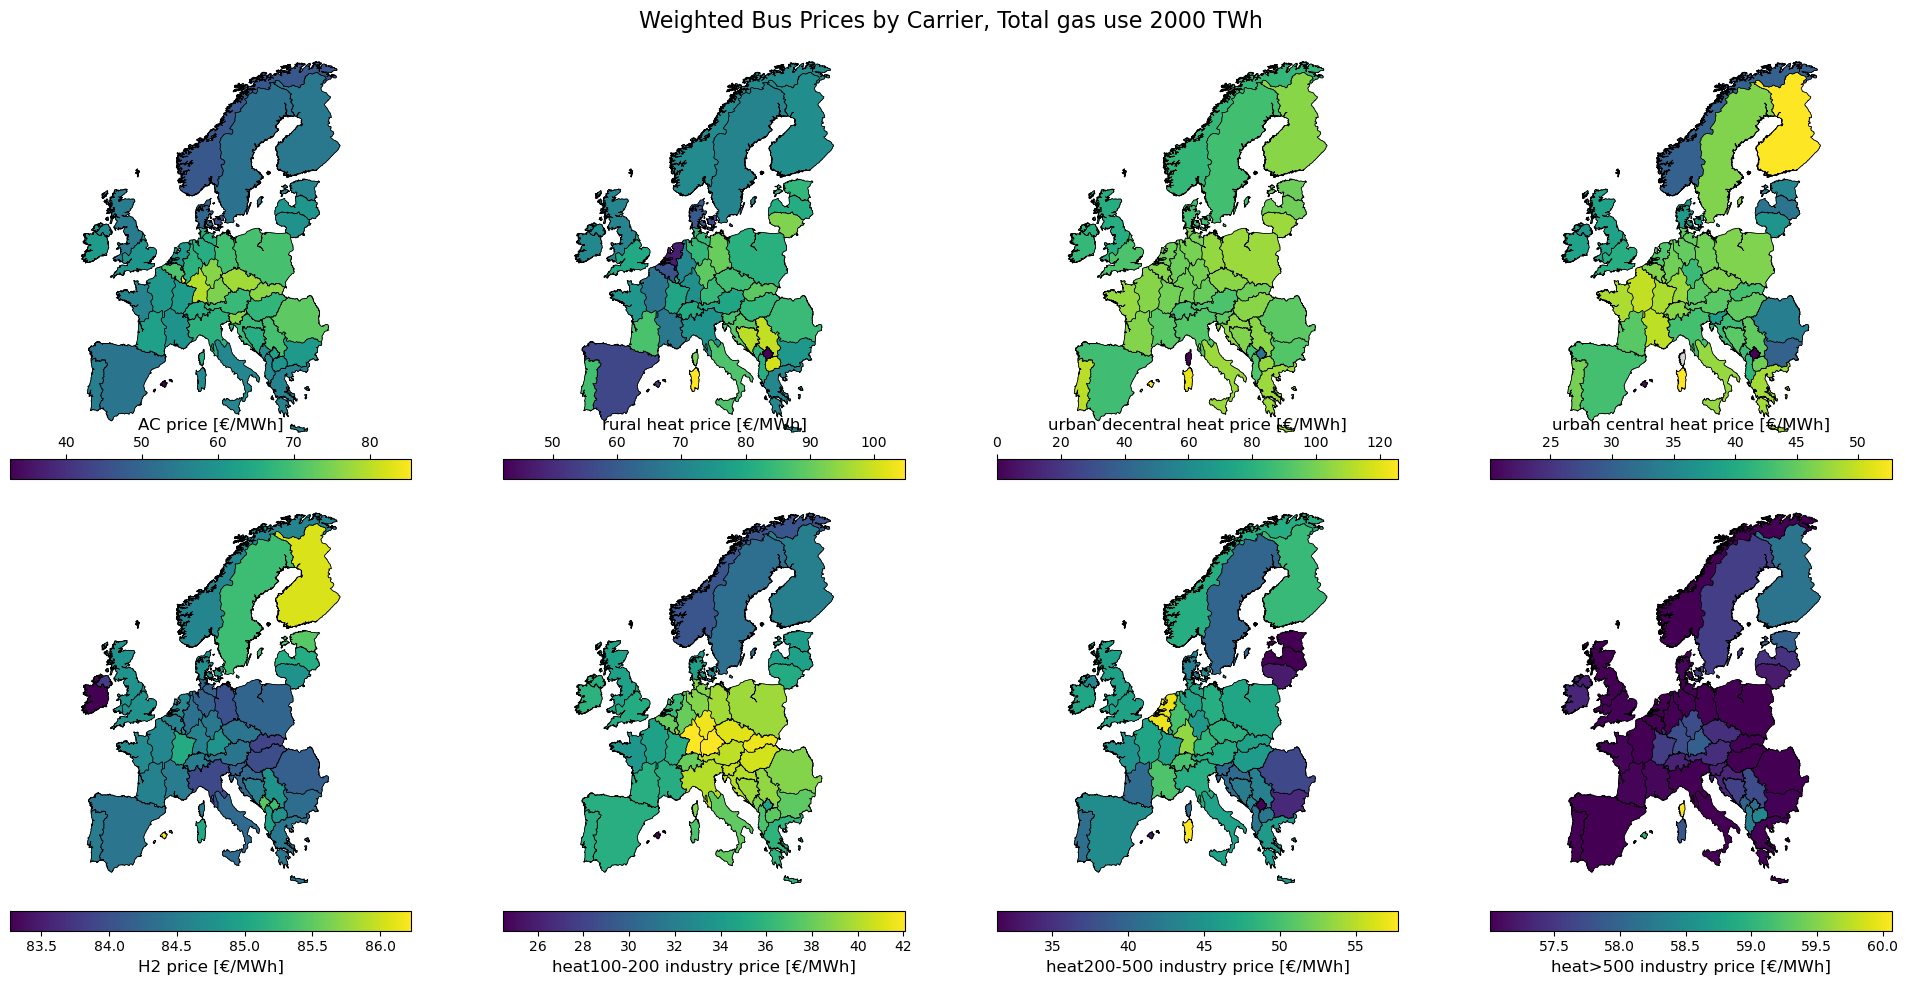

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, carrier in enumerate(carriers):
    ax = axes[idx]
    
    # Plot the map
    regions_plot.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
    
    # Get the weighted prices for this carrier
    prices = weighted_bus_prices[carrier]
    
    # Merge with regions_plot
    regions_with_prices = regions_plot.copy()
    regions_with_prices['price'] = regions_with_prices.index.map(prices)
    
    # Plot the prices
    regions_with_prices.plot(
        column='price',
        ax=ax,
        legend=False,
        edgecolor='black',
        linewidth=0.5,
        cmap='viridis',
        missing_kwds={'color': 'lightgray'}
    )
    
    # Remove spines
    ax.set_axis_off()
    
    # Add colorbar
    vmin = regions_with_prices['price'].min()
    vmax = regions_with_prices['price'].max()
    
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])
    
    # Position colorbar above for top row, below for bottom row
    if idx < 4:  # Top row
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
    else:  # Bottom row
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, fraction=0.046)
    
    cbar.set_label(carrier + ' price [€/MWh]', fontsize=12)

# Add title over the center of the plot
fig.suptitle(f'Weighted Bus Prices by Carrier, Total gas use {gasuse:.0f} TWh', fontsize=16, y=0.98)

plt.tight_layout()
plt.show()